# 📚 Predicting Student Test Scores : EDA & XGBRegressor

## 📖 Proje Amacı

Bu projenin temel amacı; öğrencilerin ders çalışma süreleri, uyku kaliteleri, derslere katılım oranları ve ebeveyn eğitim durumları gibi değişkenleri kullanarak final test skorlarını tahmin etmektir. Eğitim bilimleri perspektifinden bakıldığında bu model, hangi faktörlerin başarı üzerinde en belirleyici olduğunu anlamak adına dijital bir rehber niteliği taşır.

Tahmin edilen değer, öğrencinin sınavdan alacağı sürekli (sayısal) puandır.

---

## 🛠️ Uygulanan Makine Öğrenmesi Aşamaları

### 1. Veri Hazırlığı ve İstatistiki Analiz

Yüz binlerce öğrenci verisi üzerinde yapılan çalışmada; uyku saati, çalışma saati ve fiziksel aktivite gibi metrikler arasındaki korelasyonlar incelenmiştir. Kategorik veriler (Okul tipi, ebeveyn eğitim durumu vb.) modelin işleyebileceği sayısal formatlara dönüştürülmüş ve özellikler normalize edilmiştir.

### 2. Model Seçimi ve Hiperparametre Optimizasyonu

Projenin "şampiyon modeli" olarak belirlenen **XGBRegressor**, şu stratejik parametrelerle yapılandırılmıştır:

* **Hassas Öğrenme:** `learning_rate=0.05` ve `n_estimators=1000` kullanılarak modelin verideki küçük desenleri bile kaçırmadan, yavaş ama kararlı bir şekilde öğrenmesi sağlanmıştır.
* **Overfitting Kontrolü:** `subsample=0.8` ve `colsample_bytree=0.8` parametreleri ile modelin her seferinde verinin ve özelliklerin farklı bir kısmına bakması sağlanarak veriyi ezberlemesinin önüne geçilmiştir.
* **Performans:** `tree_method="hist"` kullanımıyla büyük veri setindeki eğitim süreci optimize edilmiştir.


<img src='https://i.ytimg.com/vi/O-nnH-BuK5I/maxresdefault.jpg' width=600>

In [1]:
# Veri analizi, matris işlemleri ve görselleştirme için gerekli temel kütüphaneleri yüklüyoruz.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Etkileşimli grafikler ve model hata analizi (residual) için gelişmiş kütüphaneleri ekliyoruz.
import plotly.express as px
from yellowbrick.regressor import ResidualsPlot

In [2]:
#veriyi oku
train=pd.read_csv('train.csv')

In [3]:
train.shape

(630000, 13)

In [4]:
# Test amaçlı küçük bir örneklemle çalış
#train = train.sample(250000)

# EDA

In [5]:
#ilk 5 satırı göster
train.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [6]:
#son 5 satırı göster
train.tail()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100
629999,629999,18,other,b.tech,3.94,75.3,yes,5.8,poor,online videos,low,easy,37.200


In [7]:
#kaç satır kaç sütun?

train.shape

(630000, 13)

In [8]:
#veriler hk bilgi

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [9]:
#boş veri kontrolü

train.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [10]:
#istatiksel bilgiler

train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.000,157499.75,314999.5,472499.25,629999.00
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [11]:
#veriler arası bağlantı,korelasyon

a=train.corr(numeric_only=True)
a

,id,age,study_hours,class_attendance,sleep_hours,exam_score
id,1.000000,-0.000581,0.000346,0.000677,0.001416,0.000372
age,-0.000581,1.000000,0.007545,0.005628,0.005864,0.010472
study_hours,0.000346,0.007545,1.000000,0.087617,0.042491,0.762267
class_attendance,0.000677,0.005628,0.087617,1.000000,0.029263,0.360954
sleep_hours,0.001416,0.005864,0.042491,0.029263,1.000000,0.167410
exam_score,0.000372,0.010472,0.762267,0.360954,0.167410,1.000000


<Axes: >

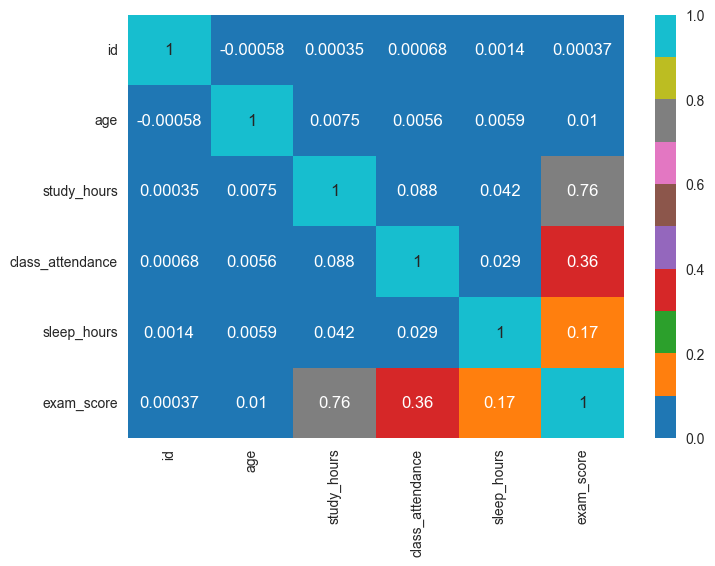

In [12]:
#sıcaklık haritası
sns.heatmap(a, annot=True, cmap='tab10')

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [14]:
train['gender'].value_counts()

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

In [15]:
train['course'].value_counts()

course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64

In [16]:
train['internet_access'].value_counts()

internet_access
yes    579423
no      50577
Name: count, dtype: int64

In [17]:
train['study_method'].value_counts()

study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64

In [18]:
train['facility_rating'].value_counts()

facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64

In [19]:
train['sleep_quality'].value_counts()

sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64

In [20]:
train['exam_difficulty'].value_counts()

exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64

# Feature Engineering

In [21]:
#Kendi kendine mi çalışıyor yoksa okul odaklı mı?
#Akademik Verimlilik (Study Efficiency)
train['Study_Per_Attendance']= train['study_hours'] / (train['class_attendance'] +1)

In [22]:
#Sadece kaç saat uyuduğu değil, uykunun kalitesiyle çarpımı gerçek dinlenmişliği verir.
#Uyku ve Yaşam Dengesi (Life Balance):
# önce sıralı (ordinal) çevir:
sleep_map = {'poor': 1, 'average': 2, 'good': 3}
train['sleep_quality_numeric'] = train['sleep_quality'].map(sleep_map)

# Sonra çarp:
train['Rest_Quality_Index'] = train['sleep_hours'] * train['sleep_quality_numeric']

In [23]:
#Bölüm ve Metot Uyumu (Interaction Features):
#Bazı bölümler (course), belirli çalışma yöntemleriyle (study_method) daha başarılı olabilir
# Sütunları araya bir ayraç koyarak birleştirmek daha okunaklı olur:
train['Course_Method_Match'] = train['course'] + "_" + train['study_method']

In [24]:
#Öğrencinin toplam çabasını ölçen bir "Gayret Endeksi"
train['Total_Effort'] = train['study_hours'] + (train['class_attendance'] / 10)

In [25]:
# Sadece en önemli 2-3 değişkenin karesini alarak modelin önünü açabilirsin
train['study_hours_sq'] = train['study_hours'] ** 2
train['attendance_sq'] = train['class_attendance'] ** 2

In [26]:
#Sınavı zorluk seviyelerine göre manuel sayısallaştırma yapıyoruz

map={'easy':0, 'moderate':1, 'hard':2}
train['exam_difficulty']=train['exam_difficulty'].map(map)

In [27]:
#sayısallaştırma
train=pd.get_dummies(train, columns=['gender', 'course', 'study_method', 'internet_access', 'sleep_quality', 'facility_rating', 'Course_Method_Match'])

# model eğitimi

In [28]:
#x ve y belirleme

x=train.drop(['id', 'exam_score'], axis=1)
y=train['exam_score']

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor,RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
    # Modelleri en verimli parametrelerle tanımlıyoruz
    L = LinearRegression()
    R = Ridge()
    # device="mps" yerine "cpu" yapıyoruz, M4 çekirdekleri için n_jobs=-1 ekliyoruz
    xgb = XGBRegressor(tree_method="hist", device="cpu", n_jobs=-1) 
    GBR = GradientBoostingRegressor()
    dt = DecisionTreeRegressor()
    
    # Sadece hızlı sonuç veren modelleri tutuyoruz (SVR ve KNN'i yine çıkardık)
    algos = [L, R, dt, xgb, GBR]
    algo_names = ['Linear', 'Ridge', 'Decision Tree', 'XGBRegressor', 'Gradient Boosting']

    # Eğitim ve test setini ayırma
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared','RMSE','MAE'], index=algo_names)
    
    for algo in algos:
        print(f"🚀 {algo.__class__.__name__} eğitiliyor...") 
        # Fit ve Predict işlemi
        model = algo.fit(x_train, y_train)
        p = model.predict(x_test)
        
        # Skorları hesapla
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p)**.5)
        mae.append(mean_absolute_error(y_test, p))
    
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae
    
    # En iyi sonucu en üstte göster
    return result.sort_values('R_Squared', ascending=False)

In [30]:
algo_test(x,y)

🚀 LinearRegression eğitiliyor...
🚀 Ridge eğitiliyor...
🚀 DecisionTreeRegressor eğitiliyor...
🚀 XGBRegressor eğitiliyor...
🚀 GradientBoostingRegressor eğitiliyor...


,R_Squared,RMSE,MAE
XGBRegressor,0.782036,8.804454,7.017744
Gradient Boosting,0.779299,8.859551,7.077242
Ridge,0.778009,8.885404,7.092431
Linear,0.778009,8.885412,7.092436
Decision Tree,0.542049,12.762008,10.090514


In [31]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [33]:
model = XGBRegressor(
    n_estimators=1000,    # Daha fazla ağaç
    learning_rate=0.05,   # Daha küçük adımlar (daha hassas öğrenme)
    max_depth=6,          # Ağaç derinliği
    subsample=0.8,        # Her adımda verinin %80'ini kullan (overfit önler)
    colsample_bytree=0.8, # Her ağaçta özelliklerin %80'ini kullan
    tree_method="hist", 
    device="cpu", 
    n_jobs=-1
)

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

In [35]:
model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cpu'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
tahmin=model.predict(x_test)

In [37]:
r2_score(tahmin, y_test)

0.7267903262464908

In [38]:
mean_squared_error(tahmin, y_test)**0.5

8.748863499140747

In [39]:
mean_absolute_error(tahmin, y_test)

6.9728943207157075

In [40]:
karsilastirma=pd.DataFrame()
karsilastirma['gercek']=y_test
karsilastirma['tahmin']=tahmin
karsilastirma

,gercek,tahmin
364426,51.3,61.307907
224752,50.6,47.386032
110423,79.9,62.491669
272555,55.4,59.932682
199651,50.4,45.655052
...,...,...
514830,22.2,27.454144
308756,97.0,97.187523
608482,52.3,55.810543
82568,56.5,56.290829


                                     Özellik      Önem
8                               Total_Effort  0.411521
21                     study_method_coaching  0.098976
1                                study_hours  0.071013
9                             study_hours_sq  0.066612
32                       facility_rating_low  0.060434
..                                       ...       ...
61             Course_Method_Match_bca_mixed  0.001099
47  Course_Method_Match_b.tech_online videos  0.001097
33                    facility_rating_medium  0.001068
11                             gender_female  0.001046
4                            exam_difficulty  0.001042

[69 rows x 2 columns]


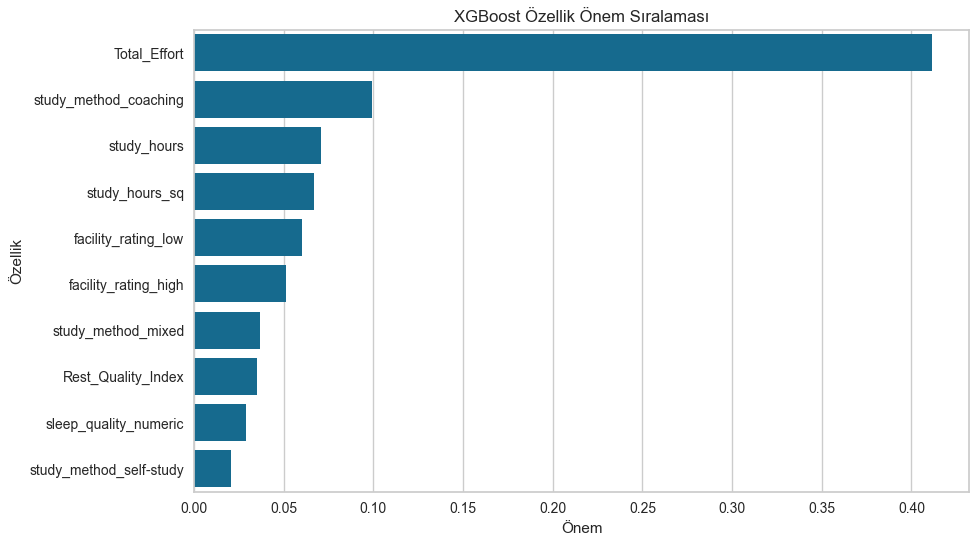

In [41]:
#hangi sütunun öğrenci puanlarını ne kadar etkilediğine bakıyoruz

importances = model.feature_importances_

# Bunu daha okunaklı bir hale getirelim
fi= pd.DataFrame({'Özellik': x.columns, 'Önem': importances})
fi = fi.sort_values(by='Önem', ascending=False)

print(fi)

# Görsel olarak görmek istersen:
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem', y='Özellik', data=fi.head(10)) # En önemli 10 özellik
plt.title('XGBoost Özellik Önem Sıralaması')
plt.show()

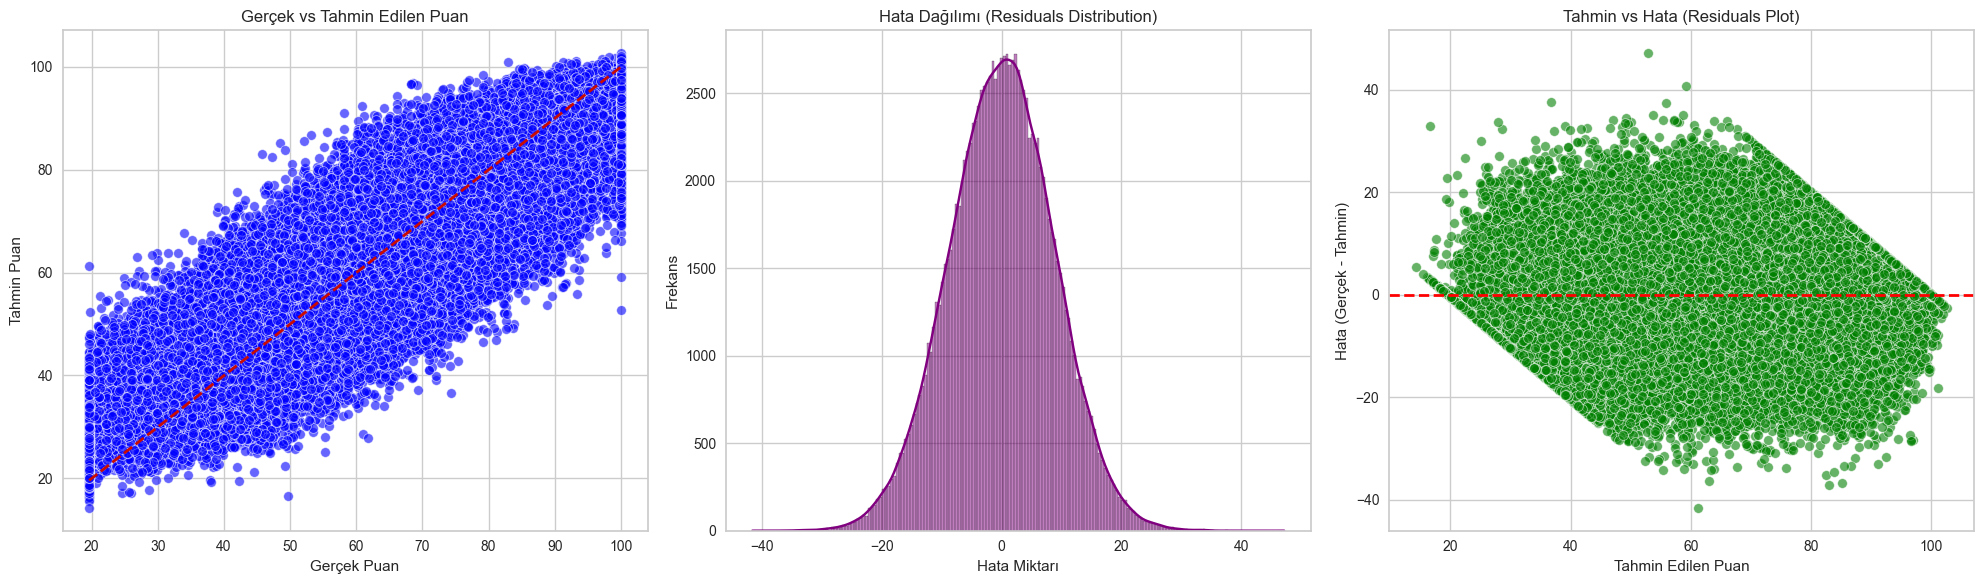

In [42]:
# 1. Residuals (Artıklar/Hatalar) Hesabı
residuals = y_test- tahmin

# Grafik alanı oluşturma (3 grafik yan yana)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- GRAFİK 1: GERÇEK VS TAHMİN ---
sns.scatterplot(x=y_test, y=tahmin, ax=axes[0], alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Gerçek vs Tahmin Edilen Puan')
axes[0].set_xlabel('Gerçek Puan')
axes[0].set_ylabel('Tahmin Puan')

# --- GRAFİK 2: HATA DAĞILIMI (Error Analysis) ---
# Gerçek değerler ile modelin tahminleri arasındaki farkı (hatayı) hesaplar.
# Pozitif değer: Gerçek puantahminden yüksek. Negatif değer: Gerçek yaş tahminden düşük.
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Hata Dağılımı (Residuals Distribution)')
axes[1].set_xlabel('Hata Miktarı')
axes[1].set_ylabel('Frekans')

# --- GRAFİK 3: RESIDUALS PLOT (Tahmin vs Hata) ---
sns.scatterplot(x=tahmin, y=residuals, ax=axes[2], alpha=0.6, color='green')
axes[2].axhline(y=0, color='red', linestyle='--', lw=2)
axes[2].set_title('Tahmin vs Hata (Residuals Plot)')
axes[2].set_xlabel('Tahmin Edilen Puan')
axes[2].set_ylabel('Hata (Gerçek - Tahmin)')

plt.tight_layout()
plt.show()

In [43]:
import joblib

# Şampiyon modelini kaydet
joblib.dump(model, 'student_test_xgb_model.pkl')
print("Model kaydedildi! 🦀")

Model kaydedildi! 🦀


# Test verisini hazırlama ve tahmin

In [50]:
test=pd.read_csv('test.csv')

In [51]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                270000 non-null  int64  
 1   age               270000 non-null  int64  
 2   gender            270000 non-null  object 
 3   course            270000 non-null  object 
 4   study_hours       270000 non-null  float64
 5   class_attendance  270000 non-null  float64
 6   internet_access   270000 non-null  object 
 7   sleep_hours       270000 non-null  float64
 8   sleep_quality     270000 non-null  object 
 9   study_method      270000 non-null  object 
 10  facility_rating   270000 non-null  object 
 11  exam_difficulty   270000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.7+ MB


In [52]:
# ID sütununu sakla
test_id = test['id']

In [53]:
#Kendi kendine mi çalışıyor yoksa okul odaklı mı?
#Akademik Verimlilik (Study Efficiency)
test['Study_Per_Attendance']= test['study_hours'] / (test['class_attendance'] +1)

#Sadece kaç saat uyuduğu değil, uykunun kalitesiyle çarpımı gerçek dinlenmişliği verir.
#Uyku ve Yaşam Dengesi (Life Balance):
# önce sıralı (ordinal) çevir:
sleep_map = {'poor': 1, 'average': 2, 'good': 3}
test['sleep_quality_numeric'] = test['sleep_quality'].map(sleep_map)

# Sonra çarp:
test['Rest_Quality_Index'] = test['sleep_hours'] * test['sleep_quality_numeric']

#Bölüm ve Metot Uyumu (Interaction Features):
#Bazı bölümler (course), belirli çalışma yöntemleriyle (study_method) daha başarılı olabilir
# Sütunları araya bir ayraç koyarak birleştirmek daha okunaklı olur:
test['Course_Method_Match'] = test['course'] + "_" + test['study_method']

#Öğrencinin toplam çabasını ölçen bir "Gayret Endeksi"
test['Total_Effort'] = test['study_hours'] + (test['class_attendance'] / 10)

# Sadece en önemli 2-3 değişkenin karesini alarak modelin önünü açabilirsin
test['study_hours_sq'] = test['study_hours'] ** 2
test['attendance_sq'] = test['class_attendance'] ** 2

#Sınavı zorluk seviyelerine göre manuel sayısallaştırma yapıyoruz

map={'easy':0, 'moderate':1, 'hard':2}
test['exam_difficulty']=test['exam_difficulty'].map(map)

#Eğer hala 'object' görünüyorsa sayıya zorla (hatalı yerleri NaN yapar)
#test['exam_difficulty'] = pd.to_numeric(test['exam_difficulty'], errors='coerce')

#sayısallaştırma
test=pd.get_dummies(test, columns=['gender', 'course', 'study_method', 'internet_access', 'sleep_quality', 'facility_rating', 'Course_Method_Match'])

In [54]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 70 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   id                                         270000 non-null  int64  
 1   age                                        270000 non-null  int64  
 2   study_hours                                270000 non-null  float64
 3   class_attendance                           270000 non-null  float64
 4   sleep_hours                                270000 non-null  float64
 5   exam_difficulty                            270000 non-null  int64  
 6   Study_Per_Attendance                       270000 non-null  float64
 7   sleep_quality_numeric                      270000 non-null  int64  
 8   Rest_Quality_Index                         270000 non-null  float64
 9   Total_Effort                               270000 non-null  float64
 10  study_ho

In [55]:
# Eğitim setindeki kolon listesini al (hedef değişken ve id hariç)
train_columns = x.columns # Daha önce x = train.drop(...) yapmıştık

# Test setini eğitim setindeki kolonlara göre yeniden düzenle
# Eğer testte eksik kolon varsa (dummies kaynaklı), onları 0 ile doldurur.
test = test.reindex(columns=train_columns, fill_value=0)

In [58]:
tahminler=model.predict(test)

In [59]:
#Kaggle Submission Dosyası Oluşturma

submission = pd.DataFrame({
    'id': test_id, # test dosyasındaki orijinal ID'ler
    'exam_score': tahminler})

In [62]:
submission.head()

,id,exam_score
0,630000,71.481491
1,630001,69.193878
2,630002,87.726166
3,630003,54.859890
4,630004,48.126072


In [61]:
# Dosyayı kaydet
submission.to_csv('submission_S6E1.csv', index=False)

# 🏁 Sonuç 

* **Model Başarısı:** Model, **%72.68 ($0.7267$)** oranında bir belirleme katsayısına ($R^2$ skoru) ulaşmıştır. Sosyolojik ve davranışsal verilerin (uyku, ders çalışma vb.) yüksek varyans içerdiği düşünüldüğünde, bu skor oldukça başarılı ve açıklayıcı bir seviyedir.